In [14]:
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
from langchain.tools import tool

from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

from pydantic import BaseModel
from typing import Annotated,TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate


In [3]:
@tool
def search(query:str):
    """This tool searches the latest news on Google Serper for the given query and returns the results."""
    search = GoogleSerperAPIWrapper()
    result = search.run(query=query)
    print(result)
    
@tool
def wiki_tool(query: str):

    """This tool allows you to search Wikipedia for information on a given topic."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)

@tool
def personal_info(name: str):

    """Use this tool to get personal information about Alice, Bob, or Charlie. 
    """

    info = {
        "Alice": "Alice is a software engineer with 5 years of experience in AI.",
        "Bob": "Bob is a data scientist who loves working with large datasets.",
        "Charlie": "Charlie is a product manager with a background in tech startups."
    }
    return info.get(name, "No information available for this person.")

In [4]:
llm = ChatGroq(
    model="openai/gpt-oss-20b"
)

In [5]:
tools = [search, wiki_tool, personal_info]
llm_with_tools = llm.bind_tools(tools)


In [11]:
class msgState(BaseModel):
    msg: Annotated[list,add_messages]

In [13]:
# 1. DEFINE STATE SCHEMA
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [16]:
def agent_node(state: AgentState):
    messages = state["messages"]
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}")
        ]
    )
    
    chain = prompt | llm_with_tools
    res = chain.invoke({"input" : messages})
    
    return {"messages": [res]}

In [32]:
def tool_node(state: AgentState):
    messages = state['messages']
    tools_by_name = {tool.name: tool for tool in tools}
    tool_results = []
    
    for tool_call in messages[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    
    return {"messages": tool_results}

In [33]:

def should_use_tool(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    
    if last_message.tool_calls:
        return "tool_node"  
    else:
        return "end"

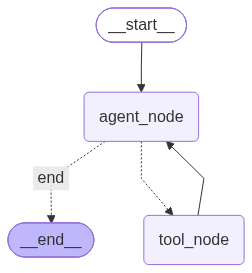

In [34]:

graph = StateGraph(AgentState)

graph.add_node("tool_node", tool_node)
graph.add_node("agent_node", agent_node)

graph.add_edge(START, "agent_node")
graph.add_conditional_edges("agent_node", should_use_tool, {
    "tool_node": "tool_node", 
    "end": END
})
graph.add_edge("tool_node", "agent_node")  # Loop back only

graph = graph.compile()
graph

In [35]:
graph.invoke({"messages": [HumanMessage(content="What is the latest news on AI?")]})

AI News delivers the latest updates in artificial intelligence, machine learning, deep learning, enterprise AI, and emerging tech worldwide. AI Weekly: AI safety fears, Spiderman star to play Sam Altman in movie · AI Weekly: New York City's AI policy for children, Anthropic's court win · AI Weekly: ... AI is developing faster than we could have imagined. What does this mean for future development and how worried should we be? The latest artificial intelligence news coverage focusing on the technology, tools and the companies building AI technology. New AI technique could make minimally invasive surgeries safer and more precise. AI for safety-critical situations. AI and machine learning materials can be ... News coverage on artificial intelligence and machine learning tech, the companies building them, and the ethical issues AI raises today. OpenAI agent 'infiltrated' Australian government website, PM says · AI superpower ambitions take centre stage as Trump and Xi meet · Is Burnham rig

{'messages': [HumanMessage(content='What is the latest news on AI?', additional_kwargs={}, response_metadata={}, id='3edb60a3-0a72-49b5-b95a-c829d71729af'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to search latest news on AI. Use search tool.', 'tool_calls': [{'id': 'fc_3b4fe8dc-279e-4fd6-9f0a-6d3fd58a4be3', 'function': {'arguments': '{"query":"latest news AI"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 251, 'total_tokens': 289, 'completion_time': 0.039599158, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.012344869, 'prompt_tokens_details': None, 'queue_time': 0.307923327, 'total_time': 0.051944027}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3cdd24b83b', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0d0d5-37a8-7991-bcb6-46e5d09b8e97-0', tool_calls=[{'name': '